In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [4]:
df=pd.read_csv("D:\\titanic_toy.csv")
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [6]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.3,random_state=42)

In [15]:
x_train.isnull().mean()

Age       0.199037
Fare      0.048154
Family    0.000000
dtype: float64

In [19]:
mean_age = x_train['Age'].mean()
median_age = x_train['Age'].median()

mean_fare = x_train['Fare'].mean()
median_fare = x_train['Fare'].median()

In [21]:
x_train['Age_median']=x_train['Age'].fillna(median_age)
x_train['Age_mean']=x_train['Age'].fillna(mean_age)
x_train['Fare_mean']=x_train['Fare'].fillna(mean_fare)
x_train['Fare_median']=x_train['Fare'].fillna(median_fare)

In [23]:
x_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_mean,Fare_median
639,NaN,16.1000,1,28.0,29.256353,16.1000,16.1000
474,22.0,9.8375,0,22.0,22.000000,9.8375,9.8375
407,3.0,18.7500,2,3.0,3.000000,18.7500,18.7500
694,60.0,26.5500,0,60.0,60.000000,26.5500,26.5500
624,21.0,16.1000,0,21.0,21.000000,16.1000,16.1000


In [25]:
print('Original Age variable variance: ',x_train['Age'].var())
print('Age Variance after median imputation: ', x_train['Age_median'].var())
print('Age Variance after mean imputation: ', x_train['Age_mean'].var())

print('Original Fare variable variance: ', x_train['Fare'].var())
print('Fare Variance after median imputation: ', x_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', x_train['Fare_mean'].var())

Original Age variable variance:  211.95188064643307
Age Variance after median imputation:  169.94984651902135
Age Variance after mean imputation:  169.69780797736954
Original Fare variable variance:  2666.9296723129796
Fare Variance after median imputation:  2552.1099348908224
Fare Variance after mean imputation:  2538.2996238091378


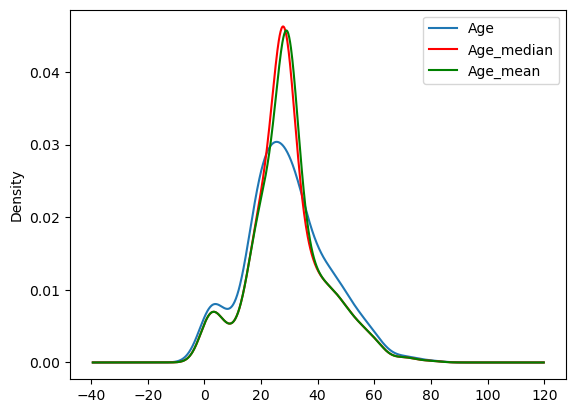

In [27]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
x_train['Age_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
x_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')


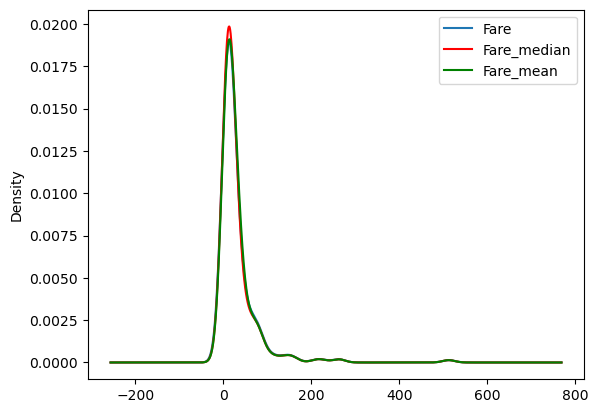

In [29]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['Fare'].plot(kind='kde', ax=ax)

# variable imputed with the median
x_train['Fare_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
x_train['Fare_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [30]:
x_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_mean,Fare_median
Age,211.951881,71.822073,-6.932603,211.951881,211.951881,67.757268,65.775061
Fare,71.822073,2666.929672,18.612474,59.765747,56.998513,2666.929672,2666.929672
Family,-6.932603,18.612474,2.997027,-5.533529,-5.550541,17.714766,17.767537
Age_median,211.951881,59.765747,-5.533529,169.949847,169.697808,56.883154,55.227061
Age_mean,211.951881,56.998513,-5.550541,169.697808,169.697808,54.249388,52.662348
Fare_mean,67.757268,2666.929672,17.714766,56.883154,54.249388,2538.299624,2538.299624
Fare_median,65.775061,2666.929672,17.767537,55.227061,52.662348,2538.299624,2552.109935


In [31]:
x_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_mean,Fare_median
Age,1.000000,0.088197,-0.310167,1.000000,1.000000,0.085804,0.083017
Fare,0.088197,1.000000,0.205140,0.088616,0.084564,1.000000,1.000000
Family,-0.310167,0.205140,1.000000,-0.245186,-0.246123,0.203104,0.203157
Age_median,1.000000,0.088616,-0.245186,1.000000,0.999258,0.086607,0.083857
Age_mean,1.000000,0.084564,-0.246123,0.999258,1.000000,0.082658,0.080023
Fare_mean,0.085804,1.000000,0.203104,0.086607,0.082658,1.000000,0.997291
Fare_median,0.083017,1.000000,0.203157,0.083857,0.080023,0.997291,1.000000


<Axes: >

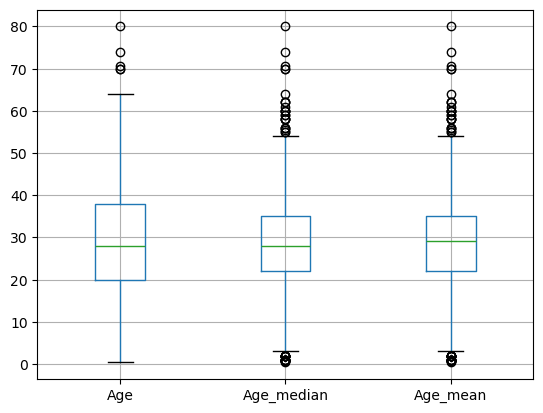

In [33]:
x_train[['Age', 'Age_median', 'Age_mean']].boxplot()

<Axes: >

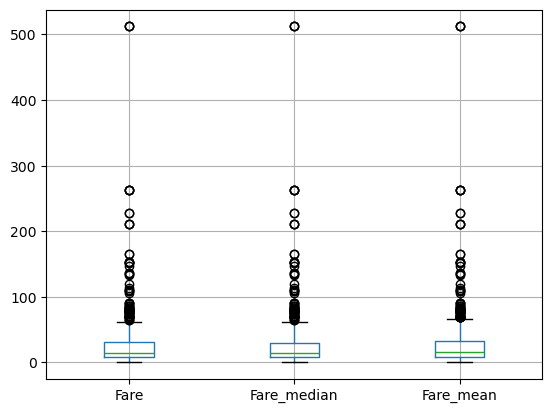

In [34]:
x_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()

using sklearn

In [35]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.3,random_state=42)


In [39]:
imputer1=SimpleImputer(strategy='median')
imputer2=SimpleImputer(strategy='mean')

In [42]:
trf=ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [45]:
trf.fit(x_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [53]:
trf.named_transformers_['imputer1'].statistics_

array([28.])

In [55]:
trf.named_transformers_['imputer2'].statistics_

array([31.79834806])

In [56]:
x_train=trf.transform(x_train)
x_test=trf.transform(x_test)

In [57]:
x_train

array([[  4.        ,  81.8583    ,   2.        ],
       [ 28.        ,   7.8958    ,   0.        ],
       [  1.        ,  11.1333    ,   2.        ],
       ...,
       [ 41.        ,  31.79834806,   2.        ],
       [ 14.        , 120.        ,   3.        ],
       [ 21.        ,  77.2875    ,   1.        ]])